# EXAM03: Data Science Group Assignment - Iteration 1

**Group name:** [Enter Group Number]

**Student names & numbers:**
* [Name 1] - [Student no.]
* [Name 2] - [Student no.]
* [Name 3] - [Student no.]


---

## 0. Setup

**Import libraries**

In [1]:
# CODE CELL: import the necessary libraries for this iteration
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:.4f}'.format)

**Load dataset(s)**

In [2]:
# CODE CELL: import the necessary dataset(s) for this iteration
df_observation = pd.read_csv("./data/Dicentrarchus labrax.csv", low_memory=False)
df_habitats = pd.read_csv("./data/habitats_cbs_2022.csv")

# df_weather = pd.read_csv("./data/weather.csv", comment='#')
df_water = pd.read_csv("./data/haringvliet_salinity_temp_daily_2010_2025.csv")

In [3]:
df_water[['salinity_mean']] = df_water[['salinity_mean']] / 1000
df_water.head()

,date,salinity_mean,temperature_mean
0,2010-01-01 00:00:00+00:00,NaN,NaN
1,2010-01-02 00:00:00+00:00,NaN,NaN
2,2010-01-03 00:00:00+00:00,NaN,NaN
3,2010-01-04 00:00:00+00:00,NaN,NaN
4,2010-01-05 00:00:00+00:00,NaN,NaN


In [4]:
df_observation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 6 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  object 
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Dicentrarchus labrax       object 
dtypes: float64(3), int64(1), object(2)
memory usage: 574.9+ MB


In [5]:
df_observation['eventDate'] = pd.to_datetime(df_observation['eventDate'])

df_obs_habitat = pd.merge(
    df_observation, 
    df_habitats, 
    on=['decimalLatitude', 'decimalLongitude'], 
    how='left'
)


df_obs_habitat['eventDate'] = pd.to_datetime(df_obs_habitat['eventDate']).dt.tz_localize(None)
df_water['date'] = pd.to_datetime(df_water['date']).dt.tz_localize(None)


df_obs_habitat_water = df_obs_habitat.merge(
    df_water,
    left_on='eventDate',
    right_on='date',
    how='left'
)

df_obs_habitat_water.drop(columns=['date'], inplace=True)


df_obs_habitat_water['Dicentrarchus labrax'] = pd.to_numeric(df_obs_habitat_water['Dicentrarchus labrax'], errors='coerce')
df_obs_habitat_water.sample(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Dicentrarchus labrax,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat,salinity_mean,temperature_mean
6744754,52.3000,4.4500,2012-02-18,0.0000,0,0.0000,0.0000,0.0062,10.4883,0.0000,0.0396,0.0000,0.0000,0.0000,coast,29.8037,4.4264
244177,50.9500,5.9500,2022-07-10,92.0000,1,0.0000,6.2288,3.0840,0.0000,1.8823,1.4424,0.0038,0.0606,0.0963,agricultural,30.6283,18.8618
10742290,53.0500,5.8500,2012-10-15,0.0000,0,0.0000,13.2629,0.5843,0.0000,0.0869,0.4669,0.0000,3.4384,0.8053,agricultural,31.8236,12.5417
636160,51.2500,5.3500,2023-09-18,10.0000,0,0.0000,7.4628,0.3791,0.0000,2.6971,0.4980,0.0030,0.2190,0.1164,agricultural,NaN,20.1226
6728645,52.2500,6.9000,2016-01-11,7.0000,0,0.0000,8.4349,3.2814,0.0000,4.1682,2.7994,0.0357,0.2302,0.0365,agricultural,33.1414,7.5914


In [6]:
print(df_obs_habitat.isnull().sum())


decimalLatitude               0
decimalLongitude              0
eventDate                     0
total_observations            1
speciesgroup_observations     0
Dicentrarchus labrax          0
agricultural                 30
built                        30
coast                        30
forest                       30
other                        30
sand/heather                 30
water                        30
wetland                      30
main_habitat                 30
dtype: int64


In [7]:
# 1. Inspect missing values 
df_missing = df_obs_habitat_water[df_obs_habitat_water.isnull().any(axis=1)]
display(df_missing.head(5))

print("Missing value counts:")
print(df_obs_habitat_water.isnull().sum())

# 2. Drop rows where habitat info is missing (geographic join failure)
habitat_cols = ['agricultural', 'built', 'coast', 'forest', 'other',
                'sand/heather', 'water', 'wetland', 'main_habitat']

df_no_missing = df_obs_habitat_water.dropna(subset=habitat_cols)


# 3. Sort by date before interpolation
df_no_missing = df_no_missing.copy()
df_no_missing = df_no_missing.sort_values('eventDate').reset_index(drop=True)

# 4. Short gaps (≤14 days): linear interpolation
df_no_missing['salinity_mean'] = (
    df_no_missing['salinity_mean']
    .interpolate(method='linear', limit=14)
)
df_no_missing['temperature_mean'] = (
    df_no_missing['temperature_mean']
    .interpolate(method='linear', limit=14)
)

# 5. Longer gaps (>14 days): fill with historical seasonal mean
df_no_missing['doy'] = pd.to_datetime(df_no_missing['eventDate']).dt.dayofyear
seasonal_sal  = df_no_missing.groupby('doy')['salinity_mean'].transform('mean')
seasonal_temp = df_no_missing.groupby('doy')['temperature_mean'].transform('mean')

df_no_missing['salinity_mean']    = df_no_missing['salinity_mean'].fillna(seasonal_sal)
df_no_missing['temperature_mean'] = df_no_missing['temperature_mean'].fillna(seasonal_temp)

df_no_missing = df_no_missing.drop(columns='doy')

# 6. Verify 
print("\nRemaining missing values after processing:")
print(df_no_missing.isnull().sum())


,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Dicentrarchus labrax,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat,salinity_mean,temperature_mean
0,50.7500,5.6500,2010-01-01,0.0000,0,0.0000,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,agricultural,NaN,NaN
1,50.7500,5.6500,2010-01-02,26.0000,0,0.0000,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,agricultural,NaN,NaN
2,50.7500,5.6500,2010-01-03,3.0000,0,0.0000,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,agricultural,NaN,NaN
3,50.7500,5.6500,2010-01-04,0.0000,0,0.0000,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,agricultural,NaN,NaN
4,50.7500,5.6500,2010-01-05,0.0000,0,0.0000,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,agricultural,NaN,NaN


Missing value counts:
decimalLatitude                    0
decimalLongitude                   0
eventDate                          0
total_observations                 1
speciesgroup_observations          0
Dicentrarchus labrax               4
agricultural                      30
built                             30
coast                             30
forest                            30
other                             30
sand/heather                      30
water                             30
wetland                           30
main_habitat                      30
salinity_mean                2529403
temperature_mean             1151894
dtype: int64


KeyboardInterrupt: 

In [ ]:
# observations with effort but no fish
true_absent = df_no_missing[(df_no_missing['total_observations'] > 0) & (df_no_missing['Dicentrarchus labrax'] == 0)]
print(f"Number of true absent records: {len(true_absent)}")

# no observations at all
no_effort = df_no_missing[df_no_missing['total_observations'] == 0]
print(f"Number of no effort records: {len(no_effort)}")

# clean no effort records
df_clean = df_no_missing[df_no_missing['total_observations'] > 0]

Number of true absent records: 6537558
Number of no effort records: 6019157


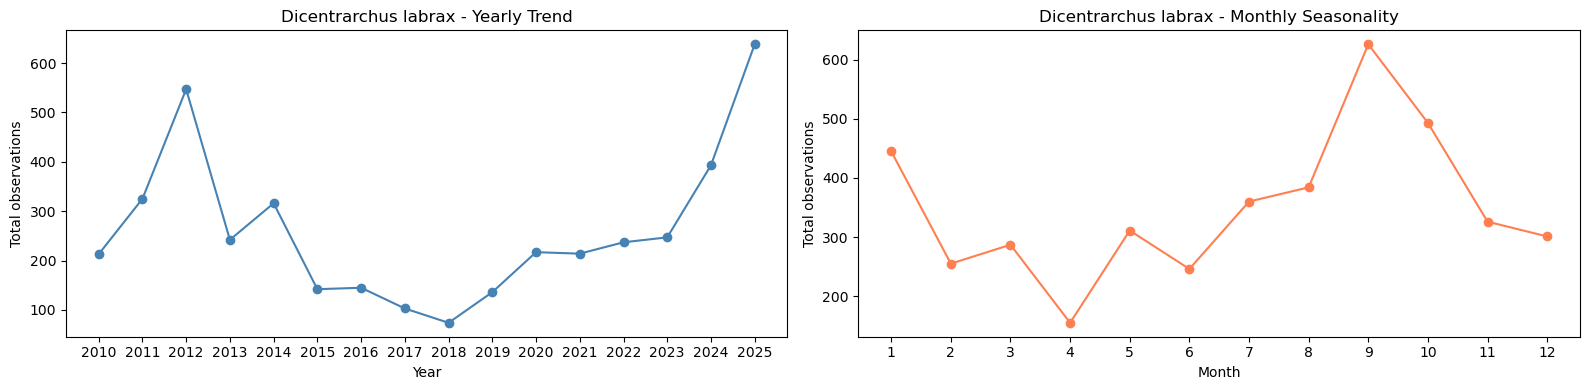

In [ ]:
# fixes the SettingWithCopyWarning
df_visual = df_clean.copy()  

df_visual['eventDate'] = pd.to_datetime(df_visual['eventDate'])
df_visual['year'] = df_visual['eventDate'].dt.year
df_visual['month'] = df_visual['eventDate'].dt.month

present_mask = df_visual['Dicentrarchus labrax'] > 0
absent_mask  = df_visual['Dicentrarchus labrax'] == 0

#Year
yearly_species = (
    df_visual.groupby('year')['Dicentrarchus labrax']
    .sum()
    .sort_index()
)

# Month seasonality 
monthly_species = (
    df_visual.groupby('month')['Dicentrarchus labrax']
    .sum()
    .reindex(range(1, 13), fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# left
yearly_species.plot(
    ax=axes[0],
    marker='o',
    color='steelblue'
)

axes[0].set_title('Dicentrarchus labrax - Yearly Trend')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total observations')

# display all years on x-axis with rotation
axes[0].set_xticks(yearly_species.index)

# right
monthly_species.plot(
    ax=axes[1],
    marker='o',
    color='coral'
)

axes[1].set_title('Dicentrarchus labrax - Monthly Seasonality')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total observations')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

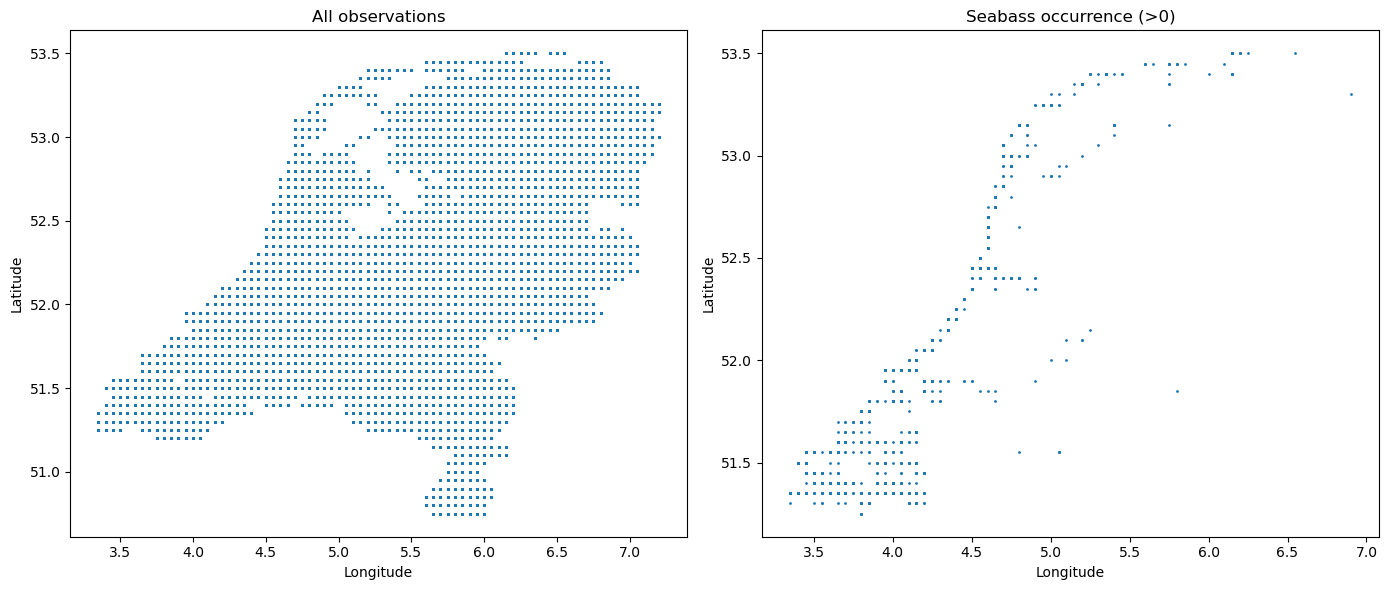

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left
axes[0].scatter(
    df_visual['decimalLongitude'],
    df_visual['decimalLatitude'],
    s=1
)
axes[0].set_title("All observations")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# right
df_seabass = df_visual[present_mask]

axes[1].scatter(
    df_seabass['decimalLongitude'],
    df_seabass['decimalLatitude'],
    s=1
)
axes[1].set_title("Seabass occurrence (>0)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()

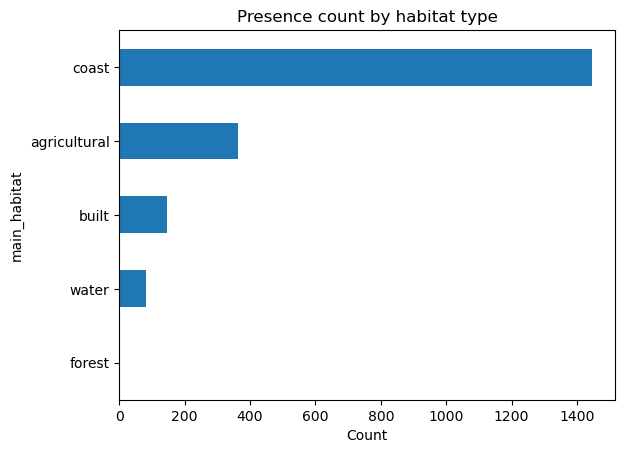

In [ ]:
df_visual[present_mask].groupby('main_habitat')['Dicentrarchus labrax'].count().sort_values().plot(kind='barh')
plt.xlabel('Count')
plt.title('Presence count by habitat type')
plt.show()

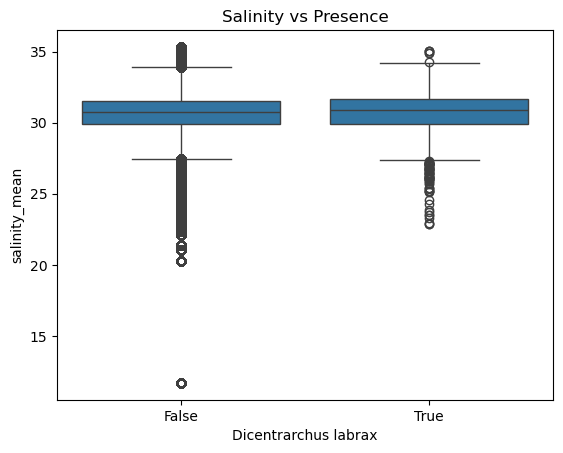

In [ ]:
sns.boxplot(data=df_visual, x=present_mask, y='salinity_mean')
plt.title("Salinity vs Presence")
plt.show()

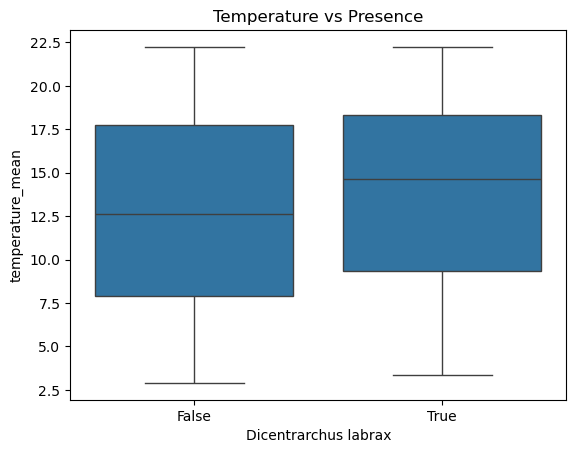

In [ ]:
sns.boxplot(data=df_visual, x=present_mask, y='temperature_mean')
plt.title("Temperature vs Presence")
plt.show()

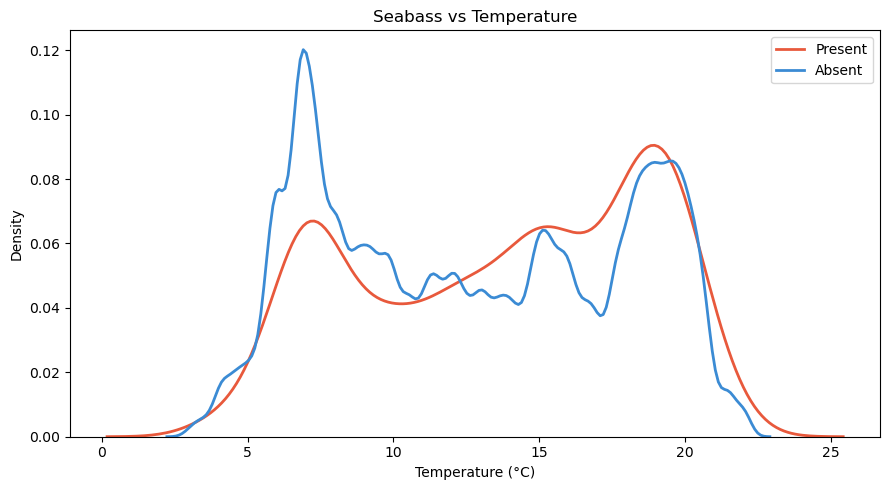

In [ ]:
present = df_visual[present_mask]['temperature_mean'].dropna()
absent  = df_visual[absent_mask]['temperature_mean'].dropna()

fig, ax = plt.subplots(figsize=(9, 5))

sns.kdeplot(present, ax=ax, color='#E8593C', linewidth=2, label='Present')
sns.kdeplot(absent,  ax=ax, color='#3B8BD4', linewidth=2, label='Absent')

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Density')
ax.set_title('Seabass vs Temperature')
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
df_clean.head(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Dicentrarchus labrax,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat,salinity_mean,temperature_mean
1,52.7000,4.9000,2010-01-01,1.0000,0,0.0000,14.0130,2.9916,0.0000,0.1010,1.3130,0.0000,0.3768,0.0000,agricultural,30.8636,7.1543
10,53.1000,6.2500,2010-01-01,3.0000,0,0.0000,13.3706,3.3326,0.0000,0.2850,1.4334,0.0000,0.2024,0.0004,agricultural,30.8636,7.1543
12,53.0000,4.8500,2010-01-01,4.0000,0,0.0000,0.3190,0.2124,17.8631,0.0000,0.2691,0.0000,0.0013,0.0000,coast,30.8636,7.1543
14,53.0000,6.3500,2010-01-01,1.0000,0,0.0000,8.1099,0.7517,0.0000,2.2248,1.0658,0.1880,0.2144,6.1126,agricultural,30.8636,7.1543
15,52.2500,5.4500,2010-01-01,6.0000,0,0.0000,8.4355,0.1978,0.0000,6.7546,1.3098,0.0023,2.1768,0.1150,agricultural,30.8636,7.1543


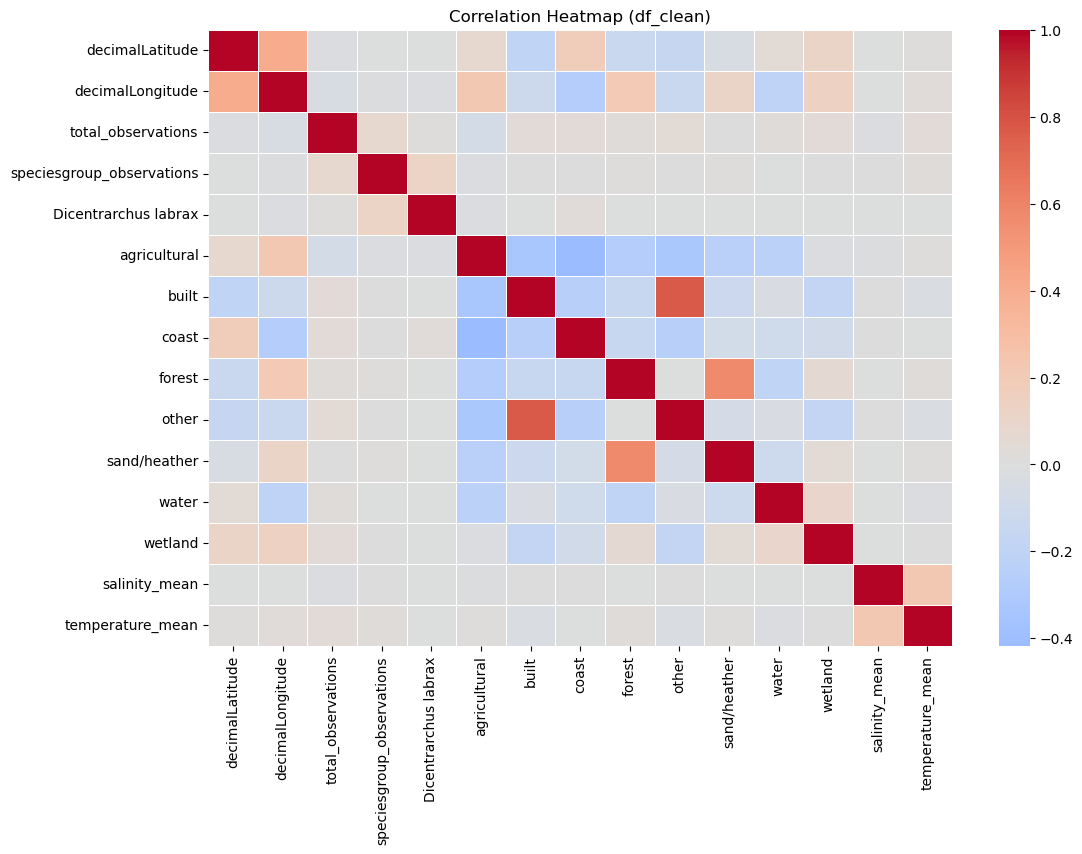

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_num = df_clean.select_dtypes(include=['number'])

corr = df_num.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap (df_clean)")
plt.show()

In [ ]:
# --- STEP 2.4: DATA CONSTRUCTION ---

# Define the target variable: 1 if present, 0 if absent
df_clean = df_clean.copy()
df_clean['target'] = (df_clean['Dicentrarchus labrax'] > 0).astype(int)

# Check the target distribution to understand class imbalance
print("Target Distribution:")
print(df_clean['target'].value_counts(normalize=True))

# Apply One-Hot Encoding to 'main_habitat'
df_final = pd.get_dummies(df_clean, columns=['main_habitat'], prefix='main_hab')

bool_cols = df_final.select_dtypes(include='bool').columns
df_final[bool_cols] = df_final[bool_cols].astype(int)

# Confirm the new columns created by OHE
print("\nNew columns after One-Hot Encoding:")
print([col for col in df_final.columns if 'main_hab' in col])

# Show the first few rows to verify
df_final.head()

Target Distribution:
target
0   0.9997
1   0.0003
Name: proportion, dtype: float64

New columns after One-Hot Encoding:
['main_hab_agricultural', 'main_hab_built', 'main_hab_coast', 'main_hab_forest', 'main_hab_other', 'main_hab_sand/heather', 'main_hab_water', 'main_hab_wetland']


,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Dicentrarchus labrax,agricultural,built,coast,forest,...,temperature_mean,target,main_hab_agricultural,main_hab_built,main_hab_coast,main_hab_forest,main_hab_other,main_hab_sand/heather,main_hab_water,main_hab_wetland
1,52.7000,4.9000,2010-01-01,1.0000,0,0.0000,14.0130,2.9916,0.0000,0.1010,...,7.1543,0,1,0,0,0,0,0,0,0
10,53.1000,6.2500,2010-01-01,3.0000,0,0.0000,13.3706,3.3326,0.0000,0.2850,...,7.1543,0,1,0,0,0,0,0,0,0
12,53.0000,4.8500,2010-01-01,4.0000,0,0.0000,0.3190,0.2124,17.8631,0.0000,...,7.1543,0,0,0,1,0,0,0,0,0
14,53.0000,6.3500,2010-01-01,1.0000,0,0.0000,8.1099,0.7517,0.0000,2.2248,...,7.1543,0,1,0,0,0,0,0,0,0
15,52.2500,5.4500,2010-01-01,6.0000,0,0.0000,8.4355,0.1978,0.0000,6.7546,...,7.1543,0,1,0,0,0,0,0,0,0


In [ ]:
# --- STEP 2.5: DATA FORMAT CONVERSION ---

# Define the feature columns: 8 habitat percentages + 8 OHE habitat indicators = 16 features
habitat_percentages = ['agricultural', 'built', 'coast', 'forest', 'other', 'sand/heather', 'water', 'wetland']
encoded_habitats = [col for col in df_final.columns if 'main_hab' in col]

all_features = habitat_percentages + encoded_habitats
# Create the feature matrix X and target vector y
X = df_final[all_features]
y = df_final['target']

# Convert to NumPy arrays for Scikit-learn
X_array = X.values
y_array = y.values

# Verify the shapes and show a sample
print("DataFrame Representation (X head - showing all 16 features):")
display(X.head())

print(f"\nNumPy Array Representation:")
print(f"X array shape: {X_array.shape}")
print(f"y array shape: {y_array.shape}")
print(f"X array sample (first row):\n{X_array[0]}")

DataFrame Representation (X head - showing all 16 features):


,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_hab_agricultural,main_hab_built,main_hab_coast,main_hab_forest,main_hab_other,main_hab_sand/heather,main_hab_water,main_hab_wetland
1,14.0130,2.9916,0.0000,0.1010,1.3130,0.0000,0.3768,0.0000,1,0,0,0,0,0,0,0
10,13.3706,3.3326,0.0000,0.2850,1.4334,0.0000,0.2024,0.0004,1,0,0,0,0,0,0,0
12,0.3190,0.2124,17.8631,0.0000,0.2691,0.0000,0.0013,0.0000,0,0,1,0,0,0,0,0
14,8.1099,0.7517,0.0000,2.2248,1.0658,0.1880,0.2144,6.1126,1,0,0,0,0,0,0,0
15,8.4355,0.1978,0.0000,6.7546,1.3098,0.0023,2.1768,0.1150,1,0,0,0,0,0,0,0



NumPy Array Representation:
X array shape: (6539599, 16)
y array shape: (6539599,)
X array sample (first row):
[14.013   2.9916  0.      0.101   1.313   0.      0.3768  0.      1.
  0.      0.      0.      0.      0.      0.      0.    ]


In [ ]:
df_ml = df_final.copy()

df_ml['target'] = (df_ml['Dicentrarchus labrax'] > 0).astype(int)

# =========================
# BALANCING
# =========================
df_pos = df_ml[df_ml['target'] == 1]
df_neg = df_ml[df_ml['target'] == 0].sample(len(df_pos) * 10, random_state=42)

df_ml = pd.concat([df_pos, df_neg])

df_ml['eventDate'] = pd.to_datetime(df_ml['eventDate']).dt.normalize()

# =========================
# feature engineering
# =========================
df_ml['year'] = df_ml['eventDate'].dt.year
df_ml['month'] = df_ml['eventDate'].dt.month
df_ml['month_sin'] = np.sin(2 * np.pi * df_ml['month'] / 12)
df_ml['month_cos'] = np.cos(2 * np.pi * df_ml['month'] / 12)

cols_to_drop = [
    'Dicentrarchus labrax',
    'speciesgroup_observations',
    'total_observations',
    'target',
    'eventDate',
    'month',
]

y = df_ml['target']
X = df_ml.drop(columns=cols_to_drop)

In [ ]:
# --- STEP 3.2: FULL SCALE TEST DESIGN (ALL DATA) ---
from sklearn.model_selection import train_test_split
import gc

# Clear any old variables to free up RAM
gc.collect()

# We use the X and y we defined in Step 3.1
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Full Training set: {X_train.shape[0]} rows")
print(f"Full Testing set: {X_test.shape[0]} rows")

Full Training set: 17960 rows
Full Testing set: 4491 rows


In [ ]:
# --- STEP 3.3: MEMORY-SAFE BIG RUN ---
from sklearn.ensemble import RandomForestClassifier

# We add 'max_samples' and 'max_depth' so your 16GB RAM doesn't crash
rf_full = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    class_weight='balanced', 
    n_jobs=-1,           # Using all 14 cores of your i9
    max_samples=None,     # RAM SAFETY: Optimization
    max_depth=15,        # RAM SAFETY: Prevents memory overflow
    verbose=1            # Shows you progress
)

rf_full.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.2s finished


RandomForestClassifier(class_weight='balanced', max_depth=15, n_jobs=-1,
                       random_state=42, verbose=1)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

rf_balanced = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1, 
    max_depth=15, 
    verbose=0 
)
rf_balanced.fit(X_train, y_train)

y_pred_test = rf_balanced.predict(X_test)
y_prob_test = rf_balanced.predict_proba(X_test)[:, 1]

print("===== BALANCED DATASET PERFORMANCE =====")
print(classification_report(y_test, y_pred_test))
print("AUC:", roc_auc_score(y_test, y_prob_test))

===== BALANCED DATASET PERFORMANCE =====
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      4083
           1       0.80      0.71      0.75       408

    accuracy                           0.96      4491
   macro avg       0.89      0.85      0.86      4491
weighted avg       0.96      0.96      0.96      4491

AUC: 0.9726994520561103


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


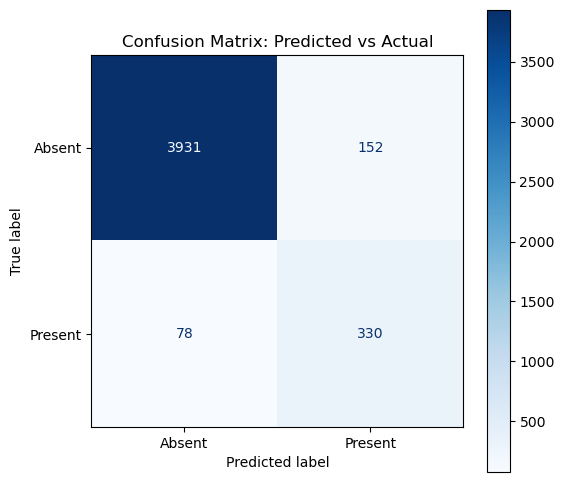

In [ ]:
# CODE CELL: Confusion Matrix Visualization
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_full = rf_full.predict(X_test)
cm = confusion_matrix(y_test, y_pred_full)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Absent', 'Present'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Predicted vs Actual')
plt.show()

/var/folders/pn/ch7h23814fl2b5bmht0fv7_w0000gn/T/ipykernel_54321/3317749449.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


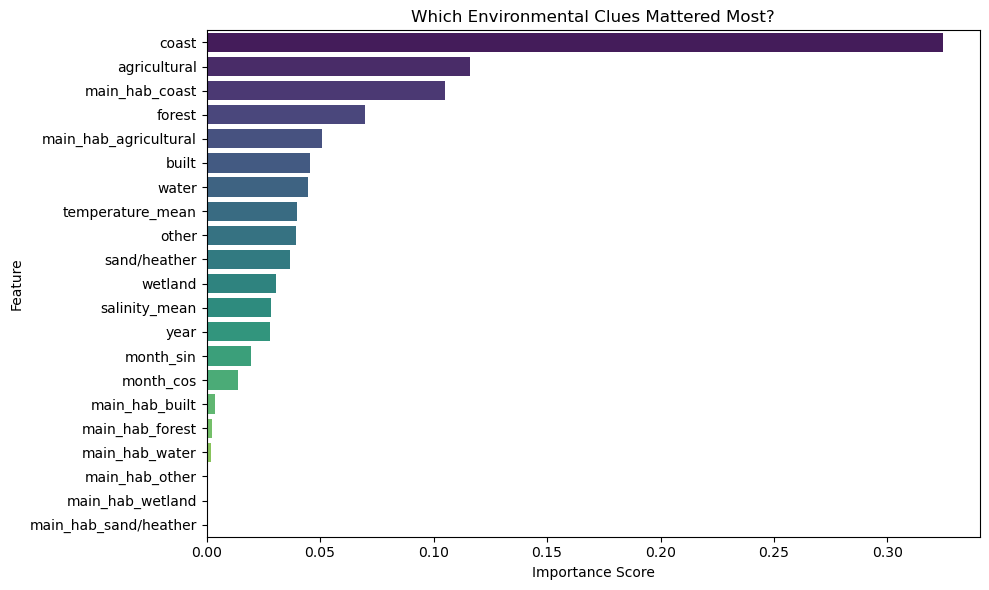

In [ ]:
# CODE CELL: Feature Importance (Which clues mattered most?)
importances = rf_full.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Which Environmental Clues Mattered Most?')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
df_full = df_final.copy()

df_full['target'] = (df_full['Dicentrarchus labrax'] > 0).astype(int)

X_full = df_full.drop(columns=[
    'Dicentrarchus labrax',
    'speciesgroup_observations',
    'total_observations',
    'target',
    'eventDate'
])

y_full = df_full['target']

# 🔥 FIX HERE (关键)
X_full = X_full.reindex(columns=X_train.columns, fill_value=0)

y_pred_full = rf_full.predict(X_full)



from sklearn.metrics import classification_report, roc_auc_score

print("===== REAL WORLD PERFORMANCE =====")
print(classification_report(y_full, y_pred_full))
print("AUC:", roc_auc_score(y_full, rf_full.predict_proba(X_full)[:,1]))

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    1.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    4.4s finished


===== REAL WORLD PERFORMANCE =====
              precision    recall  f1-score   support

           0       1.00      0.97      0.99   6537558
           1       0.01      0.76      0.02      2041

    accuracy                           0.97   6539599
   macro avg       0.50      0.87      0.50   6539599
weighted avg       1.00      0.97      0.99   6539599



[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    1.4s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    4.1s finished


AUC: 0.9807826573529894


In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# 1. 获取模型预测为 1 的原始概率
y_scores = rf_full.predict_proba(X_full)[:, 1]

# 2. 计算不同阈值下的 precision, recall 和 thresholds
precisions, recalls, thresholds = precision_recall_curve(y_full, y_scores)

# 3. 计算每个阈值对应的 F1-score
# 注意：precision_recall_curve 返回的 precisions 和 recalls 比 thresholds 多一个元素，所以切片到 len(thresholds)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

# 4. 找出让 F1-score 最大的那个最佳阈值
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"🎯 最佳分类阈值: {best_threshold:.4f}")
print(f"🚀 该阈值下的最高 F1-Score: {f1_scores[best_idx]:.4f}")

# 5. 用这个黄金阈值重新生成预测结果
y_pred_tuned = (y_scores >= best_threshold).astype(int)

# 6. 重新打印报告看看！
print("\n===== 优化阈值后的真实世界表现 =====")
print(classification_report(y_full, y_pred_tuned))

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    1.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    3.7s finished


🎯 最佳分类阈值: 0.9384
🚀 该阈值下的最高 F1-Score: 0.1476

===== 优化阈值后的真实世界表现 =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   6537558
           1       0.10      0.29      0.15      2041

    accuracy                           1.00   6539599
   macro avg       0.55      0.64      0.57   6539599
weighted avg       1.00      1.00      1.00   6539599



---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**

*Describe the Nebula Brokerage pricing problem. Why is their current "gut feeling" approach a risk?.*

**Business objective(s)**

*Justify why a data-driven baseline is needed*

**Data mining goal(s)**

*Explain what type of modeling task this is and why.*

**Success criteria**

*Determine success criteria for this iteration (the benchmark)*

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Include summary statistics and descriptions of data types below. Describe your findings.*

In [ ]:
# CODE CELL: Show basic statistics and information

**Visualizations and patterns**

*Discover patterns in the data by creating visualizations. Create at least a histogram of Galactic_Credits. Describe your observations.*

In [ ]:
# CODE CELL: Generate visualizations (e.g., scatter plots, histograms)

**Data insights and data quality**
* **Insights:** What are the key trends? What does the distribution look like? What does that mean? 
* **Quality issues:** Document missing values, duplicates, outliers, etc.

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify steps taken (e.g., imputation, handling outliers, fixing other errors).*

In [ ]:
# CODE CELL: Data cleaning and preprocessing steps

**Adjusting dataset (optional)**
*If you adjusted the dataset for modeling in additional ways, describe that here*

In [ ]:
# OPTIONAL CODE CELL: Additional preprocessing steps

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Describe and justify the creation of your simple benchmark model to predict Galactic_Credits*

In [ ]:
# CODE CELL: Model training and setup code

**Testing and performance**
*Describe how you tested the model and interpret the metrics. Make sure to present the metrics in a clear overview.*

In [ ]:
# CODE CELL: Model evaluation code

---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*What is the difference between the metrics? What does this mean? Did you meet the goals set in the Business Understanding?*

**Key findings and limitations**
*What did you learn? What are the limitations of this current model?*

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Student name 1 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 2 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 3 | *Contribution description* | *Personal lessons learned this iteration* |